# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE)

## Notebook P2-04: MCD-rPPG Preprocessing

### What this notebook does

This notebook preprocesses the **MCD-rPPG dataset** into unified HDF5 format shared across the QualityPhys pipeline.



### Why MCD-rPPG is the cornerstorne of Phase 2

MCD-rPPG is the only datase in the corpus that provides ground truth for blood pressure, SpO2, respiratory rate, arterial stiffnes, and stress level - making it the sole training signal for every target beyond HR and HRV.

## Dataset characteristics

- **600 subjects** - the largest dataset in the corpus by subject count
- **2 states** per subject: rest (`before`) and post-exercise (`after`)
- **3 cameras**
    - `FullHDwebcam` — **frontal view**  selected for rPPG
    - `USBVideo` — **left profile view**  unsuitable for POS/MediaPipe
    - `IriunWebcam` — **right profile view**  unsuitable for POS/MediaPipe
- **PPG at 100 Hz** - higher sampling rate than any previous dataset
- **ECG available** - enables high-quality HRV computation like ECG-Fitness
- **13 health biomarkers** - the most comprehensive label set in the corpus
- Recordings are **3 minutes** each

### Reference strategy

ECG covers only ~30 s - used for high-quality HRV (RMSSD, SDNN, pNN50)
PPG covers ~180 s - used for `hr_continuous` and `reference_signal`.
`reference_type = "ECG_hrv_PPG_continuous"` documents this hybrid approach



### Biomarker handling strategy

Not all 13 biomarkers are equally feasible as rPPG estimation targets.
This notebook stores all of them in the HDF5, but the metadata clearly documents each biomarker's feasibility tier so the training code can select the appropiate targets:

| Biomarker | Type | Feasibility | Notes |
|-----------|------|-------------|-------|
| Systolic BP | signal-derived | Experimental | PTT/morphology approach |
| Diastolic BP | signal-derived | Experimental | PTT/morphology approach |
| SpO₂ | signal-derived | Experimental | R/G ratio approach |
| Respiratory rate | signal-derived | Confident | RSA from RR intervals |
| Arterial stiffness | signal-derived | Experimental | Pulse wave analysis |
| Stress (PSM-25) | scalar label | Experimental | HRV correlates |
| Age | demographic | Conditioning | Input feature, not target |
| Sex | demographic | Conditioning | Input feature, not target |
| BMI | demographic | Conditioning | Input feature, not target |
| Temperature | scalar | Not feasible | No RGB mechanism |
| Glycated Hb | scalar | Not feasible | No validated mechanism |
| Cholesterol | scalar | Not feasible | No validated mechanism |

### Dataset file structure

```
data/
├── db.csv  <- master metadata: one row per recording
│              columns: subject_id, state, camera,
│              video_path, ppg_path, ecg_path,
│              + all 13 biomarkers
└── video/
    ├── 1020_USBVideo_before.avi 
    ├── 1020_USBVideo_after.avi  
    ├── 1020_FullHDwebcam_before.avi <- frontal webcam, rest state
    ├── 1020_FullHDwebcam_after.avi <- frontal webcam, post-exercise
    ├── 1020_IriunWebcam_before.avi
    └── 1020_IriunWebcam_after.avi
```

Naming convention: `{subject_id}_{camera}_{state}.avi`
PPG and ECG signals are referenced in `db.csv`.

### Pipeline

```
{subject_id}_FullHDwebcam_{state}.avi 
    │
    ├─ 1 BGR → RGB 
    ├─ 2 MediaPipe Face Mesh -> ROI masks (forehead, cheeks)
    └─ 3 Spatial mean RGB per ROI -> [T, 3_ROIs, 3_ch]
           │
           └─ 4 Bandpass 0.7–3.5 Hz -> POS -> rPPG signal [T]

ECG signal (from db.csv reference, 500 Hz)
    │
    ├─ 5 Bandpass 0.5–40 Hz (ECG clinical range)
    ├─ 6 R-peak detection (NeuroKit2 Pan-Tompkins)
    └─ 7 HR, RR intervals, RMSSD, SDNN, pNN50, ECG SQI

PPG signal (100 Hz, for cross-validation and SpO₂ channel ratio)
    │
    ├─ 8 Bandpass 0.5–8 Hz
    ├─ 9 Peak detection for cross-check against ECG HR
    └─ 10 Resample to video FPS

 11 rPPG SQI + ECG SQI - both computed (like ECG-Fitness)
 12  Biomarker validation -  range checks on all 13 biomarkers
 13  Write to HDF5 - signals + biomarkers as attributes
```


## 1. Enviroment Setup

In [1]:
import subprocess, sys

packages = [
    "neurokit2",
    "mediapipe",
    "h5py",
    "opencv-python",
    "scipy",
    "numpy",
    "pandas",
    "matplotlib"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages confirmed.")

All packages confirmed.


## 2. Imports and Configuration

The configuration cell for MCD-rPPG is the most extensive in the corpus because it must handle camera selection, state selection, the biomarker tier system.


In [2]:
import os, warnings, cv2, h5py, urllib.request, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from scipy.signal import butter, filtfilt
warnings.filterwarnings("ignore")

# Plot style 
plt.rcParams.update({
    "figure.facecolor" : "#0f0f0f",
    "axes.facecolor" : "#1a1a2e",
    "axes.edgecolor" : "#444444",
    "axes.labelcolor" : "#e0e0e0",
    "xtick.color" : "#e0e0e0",
    "ytick.color" : "#e0e0e0",
    "text.color" : "#e0e0e0",
    "grid.color"  : "#2a2a3e",
    "grid.linestyle" : "--",
    "grid.alpha" : 0.5,
    "figure.dpi" : 110,
})

# Paths 
MCD_DIR = "F:/MCD-rppg/MCD_rPPG_dataset"
OUTPUT_DIR = "E:/QualityPhys"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Dataset identity
DATASET_NAME = "mcd_rppg"
HDF5_PATH = os.path.join(OUTPUT_DIR, "mcd_rppg.h5")


# Camera selection
# Three cameras recorded simultaneously:
# FullHDwebcam - front selected
# USBVideo - left webcam 
# IriunWebcam - mobile phone camera (variable fps, least stable)

CAMERA_SELECT = "FullHDwebcam"

# State selection
# before = resting state (baseline HR, BP)
# after = post-exercise state (elevated HR, BP)
STATES = ["before", "after"]
STATE_NAMES = {"before" : "rest", "after" : "post_exercise"}

# Signal processing parameters
FPS = 29.90   # FullHDwebcam actual
ECG_FS = 500.0 # confirmed from JSON - medical grade ECG device 
PPG_FS = 100.0 # PPG sampling rate 
ECG_DURATION_S = 30.0  # ECG diagnostic strip duration

# rPPG bandpass - identical across all QualityPhys notebooks
RPPG_BP_LOW, RPPG_BP_HIGH = 0.7, 3.5

# ECG bandpass - identical to ECG-Fitness
ECG_BP_LOW, ECG_BP_HIGH = 0.5, 40.0

# PPG badpass - identical to UBFC-rPPG
PPG_BP_LOW, PPG_BP_HIGH = 0.5, 8.0


# Signal Quality Index thresholds
RPPG_SQI_THRESHOLD = 0.4
ECG_SQI_THRESHOLD = 0.5

# HR limits - post-exercise can reach higher HR 
HR_MIN = 40
HR_MAX = 200

# Biomarker tier system
# All 13 biomarkers are stored in HDF5, but tiered by feasibility as rPPG estimation 
# targets. The training code uses this to select targets.
# tier_1_confident : derivable from rPPG with solid literature support
# tier_2_experimental : may be derivable
# tier_3_conditioning: uses as model input features, not prediction targets
# tier_4_not_feasible: store for completeness
BIOMARKER_TIERS = {
    # Tier 1 - confident
    "respiratory_rate" : "tier_1_confident",

    # Tier 2 - experimental 
    "systolic_bp" : "tier_2_experimental", # classification (hypertensive/normotensive) - more feasible than continuous mmHg estimation, 
                                           # requires cuff calibration for continuous use 
    "diastolic_bp" : "tier_2_experimental", # same caveat as systolic
    "spo2" : "tier_2_experimental",
    "arterial_stiffness" : "tier_2_experimental",  
    "stress_psm25" : "tier_2_experimental", # stress index, scale 1–10 (not PSM-25 total)

    # Tier 3 - conditioning inputs (model receives these, does not predict them)
    "age" : "tier_3_conditioning",
    "sex" : "tier_3_conditioning",
    "bmi" : "tier_3_conditioning",

    # Tier 4 - not feasible via rPPG, store but never use as traning target
    "temperature" : "tier_4_not_feasible",
    "glycated_hb" : "tier_4_not_feasible",
    "cholesterol" : "tier_4_not_feasible",
    "hemoglobin" : "tier_4_not_feasible",
}

# Physiologically plausible ranges for biomarker validation
# Any value outside these ranges is flagged as suspicious
BIOMARKER_RANGES = {
    "systolic_bp" : (70, 220), # mmHg
    "diastolic_bp" : (40, 130), # mmHg 
    "spo2" : (85, 100), # %
    "respiratory_rate" : (6, 40), # breaths/min 
    "arterial_stiffness" : (3, 18), # m/s (PWV)
    "stress_psm25" : (0, 10), # actual range confirmed: 1–7.52, likely 1–10 scale
    "age" : (18, 90), # years
    "bmi" : (16, 60), # kg/m²
    "temperature" : (35, 40), # °C
    "glycated_hb" : (4, 15), # %
    "cholesterol" : (2, 12), # mmol/L
    "hemoglobin" : (7, 20), # g/dl - normal 12-18, pathological below 7
}

# ROI landmark indices 

FOREHEAD_LM = [10, 338, 297, 332, 284, 251, 389, 356, 454,
               323, 361, 288, 397, 365, 379, 378, 400, 377,
               152, 148, 176, 149, 150, 136, 172, 58,  132,
               93,  234, 127, 162, 21,  54,  103, 67,  109]

LEFT_CHEEK_LM  = [234, 227, 116, 123, 147, 213, 192, 214, 210,
                  211, 206, 203, 36,  101, 119, 229, 228]

RIGHT_CHEEK_LM = [454, 447, 345, 352, 376, 433, 416, 434, 430,
                  431, 426, 423, 266, 330, 348, 449, 448]

ROI_CONFIGS = {
    "forehead" : FOREHEAD_LM,
    "left_cheek" : LEFT_CHEEK_LM,
    "right_cheek" : RIGHT_CHEEK_LM,
}

print("Configuration loaded.")
print(f"Dataset path : {MCD_DIR}")
print(f"Output HDF5  : {HDF5_PATH}")
print(f"Camera : {CAMERA_SELECT}")
print(f"States : {STATES}")
print(f"ECG/PPG rate : {ECG_FS} Hz")
print(f"FPS : {FPS}")
print(f"rPPG bandpass : {RPPG_BP_LOW}–{RPPG_BP_HIGH} Hz")
print(f"ECG bandpass : {ECG_BP_LOW}–{ECG_BP_HIGH} Hz")
print()
print("Biomarker tiers:")
from collections import Counter
tier_counts = Counter(BIOMARKER_TIERS.values())
for tier, count in sorted(tier_counts.items()):
    print(f"{tier:<20}: {count} biomarkers")

Configuration loaded.
Dataset path : F:/MCD-rppg/MCD_rPPG_dataset
Output HDF5  : E:/QualityPhys\mcd_rppg.h5
Camera : FullHDwebcam
States : ['before', 'after']
ECG/PPG rate : 500.0 Hz
FPS : 29.9
rPPG bandpass : 0.7–3.5 Hz
ECG bandpass : 0.5–40.0 Hz

Biomarker tiers:
tier_1_confident    : 1 biomarkers
tier_2_experimental : 5 biomarkers
tier_3_conditioning : 3 biomarkers
tier_4_not_feasible : 4 biomarkers


## 3. Dataset Exploration

In [3]:
# Directory structure?
print("Root directory contents:")
if os.path.exists(MCD_DIR):
    for item in sorted(os.listdir(MCD_DIR)):
        item_path = os.path.join(MCD_DIR, item)
        size = os.path.getsize(item_path) / 1e6 if os.path.isfile(item_path) else None
        print(f"{item:<40} {size:.1f} MB" if size else f"{item}")
else:
    print(f"Warning: {MCD_DIR} does not exist yet.")

print()

# db.csv 
db_path = os.path.join(MCD_DIR, "db.csv")
if os.path.exists(db_path):
    df_db = pd.read_csv(db_path)
    print(f"db.csv shape: {df_db.shape[0]} rows x {df_db.shape[1]} columns")
    print()
    print("Column names:")
    for col in df_db.columns:
        dtype = df_db[col].dtype
        n_unique = df_db[col].nunique()
        sample   = df_db[col].dropna().iloc[0] if df_db[col].notna().any() else "NaN"
        print(f"{col:<30} dtype={str(dtype):<10} unique={n_unique:<6} sample={sample}")
    print()
    print("Camera -> view mapping:")
    print(df_db[["camera", "view"]].drop_duplicates().sort_values("camera").to_string(index=False))
    print()
    print("First 3 rows:")
    print(df_db.head(3).to_string())
else:
    print("db.csv not found.")
print()

# FPS per camera froma actual video headers
video_dir = os.path.join(MCD_DIR, "video")
if os.path.exists(video_dir):
    print("FPS per camera:")
    for camera in ["FullHDwebcam", "USBVideo", "IriunWebcam"]:
        camera_rows = df_db[df_db["camera"] == camera]
        if len(camera_rows) == 0:
            continue
        sample_path = os.path.join(MCD_DIR, camera_rows.iloc[0]["video"])
        if os.path.exists(sample_path):
            cap = cv2.VideoCapture(sample_path)
            fps_actual = cap.get(cv2.CAP_PROP_FPS)
            w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            cap.release()
            view = camera_rows.iloc[0]["view"]
            suitable = "OK" if view =="front" else "X"
            print(f"{camera:<16} FPS={fps_actual:.2f} {w}x{h} frames={n} view={view} {suitable}")
    print()

# ECG format
ecg_sample = df_db[df_db["ecg"].notna()].iloc[0]["ecg"]
ecg_path = os.path.join(MCD_DIR, ecg_sample)
if os.path.exists(ecg_path):
    with open(ecg_path) as file:
        ecg_j = json.load(file)
    leads = [lead["title"] for lead in ecg_j["data"]]
    n_samp = len(ecg_j["data"][0]["values"])
    ecg_fs_actual = float(ecg_j["frequency"])
    print(f"ECG: {ecg_sample}")
    print(f"frequency={ecg_fs_actual} Hz leads={leads} samples={n_samp} ({n_samp/ecg_fs_actual:.0f}s)")
print()

# PPG format
ppg_sample = df_db[df_db["ppg"].notna()].iloc[0]["ppg"]
ppg_path = os.path.join(MCD_DIR, ppg_sample)
if os.path.exists(ppg_path):
    df_pw = pd.read_csv(ppg_path, sep=r"\s+", header=None, dtype=str, nrows=5)
    print(f"PPG sample ({ppg_sample}) - first 5 lines:")
    print(df_pw.to_string(index=False, header=False))
    print("Format: integer_amplitude  YYYY-MM-DD HH:MM:SS.ffffff")
print()

# Biomarker availability 
print("Biomarker column availability in db.csv:")
for bm_internal, bm_raw in [
    ("systolic_bp","upper_ap"), ("diastolic_bp","lower_ap"),
    ("spo2","saturation"), ("respiratory_rate","respiratory"),
    ("arterial_stiffness","rigidity"), ("stress_psm25","stress"),
    ("glycated_hb","glycated_hemoglobin"), ("cholesterol","cholesterol"),
    ("hemoglobin","hemoglobin"), ("temperature","temperature"), ("age","age"), 
    ("sex","sex"), ("bmi","bmi"),
]:
    present = bm_raw in df_db.columns
    n_valid = df_db[bm_raw].notna().sum() if present else 0
    tag = f"{n_valid}/{len(df_db)}" if present else "NOT IN DATASET"
    print(f"{bm_raw:<25} -> {bm_internal:<22} {tag}")


Root directory contents:
.cache
.gitattributes                           0.3 MB
README.md                                0.0 MB
db.csv                                   0.9 MB
ecg
meta
ppg
ppg_sync
readme.txt                               0.0 MB
video

db.csv shape: 3600 rows x 25 columns

Column names:
patient_id                     dtype=int64      unique=600    sample=1020
weight                         dtype=float64    unique=71     sample=55.0
height                         dtype=float64    unique=46     sample=170.0
bmi                            dtype=float64    unique=436    sample=19.031141868512112
age                            dtype=float64    unique=40     sample=23.0
sex                            dtype=object     unique=2      sample=F
upper_ap                       dtype=float64    unique=97     sample=113.0
lower_ap                       dtype=float64    unique=53     sample=78.0
saturation                     dtype=float64    unique=11     sample=98.0
temperature     

## 4. Build Recording Inventory

The inventory links each video file to its ECG/PPG signals and biomarker labels from `db.csv`. One row per (subject, state) combination for the selected camera.



In [4]:
def build_inventory(mcd_dir: str, camera: str, states: list) -> pd.DataFrame:
    """
    Build a per-recording inventory from db.csv.
    
    db.csv has one row per (subject x state x camera) - 3600 rows total.
    Filter to selected camera and states, then resolve ECG/PPG/video
    paths directly from db.csv columns rather than contructing manually.
    
    Note: ECG and PPG files are shared across all three cameras for the same
    subject/state — each subject has one ecg/1020_after.json regardless of
    which camera row is selected.
    """
    db_path = os.path.join(mcd_dir, "db.csv")
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"db.csv not found at {db_path}")
    df_db = pd.read_csv(db_path)

    # Step 1: Filter to selected camera and states
    # db.csv contains all three cameras - only selected one is needed - this reduces 3600 rows to 600 * len(states) rows.
  

    df_cam = df_db[(df_db["camera"] == camera) & (df_db["step"].isin(states))].copy().reset_index(drop=True)

    print(f"Rows after filter: {len(df_cam)} (expected {600 * len(states)})")

    # Step 2: Rename db.csv columns to internal names
    # Maps actual db.csv column names to the standardised internal names used throughout the pipeline.
                    
    COLUMN_MAP = {
        "patient_id" : "subject_id",
        "step" : "state",
        # Biomarkers 
        "upper_ap" : "systolic_bp",
        "lower_ap" : "diastolic_bp",
        "saturation" : "spo2",
        "glycated_hemoglobin" : "glycated_hb",
        "cholesterol" : "cholesterol",
        "respiratory" : "respiratory_rate",
        "rigidity" : "arterial_stiffness",
        "stress" : "stress_psm25",
        # These already match internal names - no rename needed: temperature, cholesterol, age, sex, bmi, hemoglobin
    }
    df_cam = df_cam.rename(columns={key: value for key, value in COLUMN_MAP.items() if key in df_cam.columns})
    
    # Step 3: Build one record per row
    records = []

    for _, row in df_cam.iterrows():
        subject_id = int(row["subject_id"])
        state = row["state"]

        # Resolve absolute paths from db.csv relative paths
        video_path = os.path.join(mcd_dir, row["video"])
        ecg_path = os.path.join(mcd_dir, row["ecg"])
        ppg_path = os.path.join(mcd_dir, row["ppg"])
        
        has_video = os.path.exists(video_path)
        has_ecg = os.path.exists(ecg_path)
        has_ppg = os.path.exists(ppg_path)

        # Collect biomarker values - use NaN if column missing after rename
        biomarkers = {}
        for biomarker in BIOMARKER_TIERS.keys():
            raw = row.get(biomarker, np.nan)
            try:
                biomarkers[biomarker] = float(raw)
            except (ValueError, TypeError):
                # Keep as string for categorical biomarkers (e.g. sex: 'F'/'M')
                biomarkers[biomarker] = raw

        record = {
            "subject_id" : subject_id,
            "state" : state,
            "state_name" : STATE_NAMES.get(state, state),
            "camera" : camera,
            "video_path" : video_path if has_video else None,
            "ppg_path" : ppg_path if has_ppg else None,
            "ecg_path" : ecg_path if has_ecg else None,
            "complete" : has_video, 
            "has_ecg" : has_ecg,
            "has_ppg" : has_ppg,
        }
        record.update(biomarkers)
        records.append(record)
            
    df = pd.DataFrame(records).sort_values(["subject_id", "state"]).reset_index(drop=True)
    return df

# Run inventory
df_inventory = build_inventory(MCD_DIR, CAMERA_SELECT, STATES)

print(f"Recordings in inventory : {len(df_inventory)}")
print(f"Complete (video found) : {df_inventory["complete"].sum()}")
print(f"With ECG file : {df_inventory["has_ecg"].sum()}")
print(f"With PPG file : {df_inventory["has_ppg"].sum()}")
print(f"Expected complete : {600 * len(STATES)} (600 subjects x {len(STATES)} states)")
print() 


# Biomarker coverage - how many recordings have each biomarker
print("Biomarker coverage (non-NaN values):")
for biomarker in BIOMARKER_TIERS.keys():
    if biomarker in df_inventory.columns:
        n_valid = df_inventory[biomarker].notna().sum()
        tier = BIOMARKER_TIERS[biomarker]
        print(f"{biomarker:<25} {n_valid:>5}/{len(df_inventory)} [{tier}]")
    else:
        print(f"{biomarker:<25} COLUMN NOT FOUND")


print()
print("State distribution:")
print(df_inventory.groupby("state")["complete"].agg(["sum", "count"]).rename(columns={"sum" : "complete", "count": "total"}).to_string())
print()
print("Stress range check:")
if "stress_psm25" in df_inventory.columns:
    s = df_inventory["stress_psm25"].dropna()
    print(f"min={s.min():.2f}  max={s.max():.2f}  mean={s.mean():.2f}  "
          f"(confirmed not full PSM-25 — ordinal 1-10 scale)")


Rows after filter: 1200 (expected 1200)
Recordings in inventory : 1200
Complete (video found) : 1200
With ECG file : 1200
With PPG file : 1200
Expected complete : 1200 (600 subjects x 2 states)

Biomarker coverage (non-NaN values):
respiratory_rate           1200/1200 [tier_1_confident]
systolic_bp                1200/1200 [tier_2_experimental]
diastolic_bp               1200/1200 [tier_2_experimental]
spo2                       1200/1200 [tier_2_experimental]
arterial_stiffness         1200/1200 [tier_2_experimental]
stress_psm25               1200/1200 [tier_2_experimental]
age                        1200/1200 [tier_3_conditioning]
sex                        1200/1200 [tier_3_conditioning]
bmi                        1200/1200 [tier_3_conditioning]
temperature                1200/1200 [tier_4_not_feasible]
glycated_hb                1200/1200 [tier_4_not_feasible]
cholesterol                1200/1200 [tier_4_not_feasible]
hemoglobin                 1200/1200 [tier_4_not_feasible]

Sta

## 5. Biomarker Inspection and Validation


Validate biomarker distributions before processing any signals.

**Confirmed dataset characteristics:**
- `sex` is a string column ('F'/'M'), not numeric - handled separately
- `stress_psm25` range is 1–7.52 (ordinal scale, NOT PSM-25 total 0–100)

45 out-of-range values detected:
 subject_id  state          biomarker     value allowed
       1259  after arterial_stiffness 26.590000    3-18
       2022  after arterial_stiffness 21.540000    3-18
       2147 before arterial_stiffness 21.710000    3-18
       2446  after arterial_stiffness  2.260000    3-18
       2842  after arterial_stiffness 19.430000    3-18
       3133 before arterial_stiffness  2.190000    3-18
       3192 before arterial_stiffness  1.750000    3-18
       4430  after arterial_stiffness  2.410000    3-18
       4731  after arterial_stiffness 23.860000    3-18
       4929 before arterial_stiffness 21.540000    3-18
       5214  after arterial_stiffness 34.020000    3-18
       5733  after arterial_stiffness 18.780000    3-18
       6091 before arterial_stiffness  2.850000    3-18
       6145  after arterial_stiffness 18.310000    3-18
       6856  after arterial_stiffness 19.660000    3-18
       6856 before arterial_stiffness 27.860000    3-18
       7626 bef

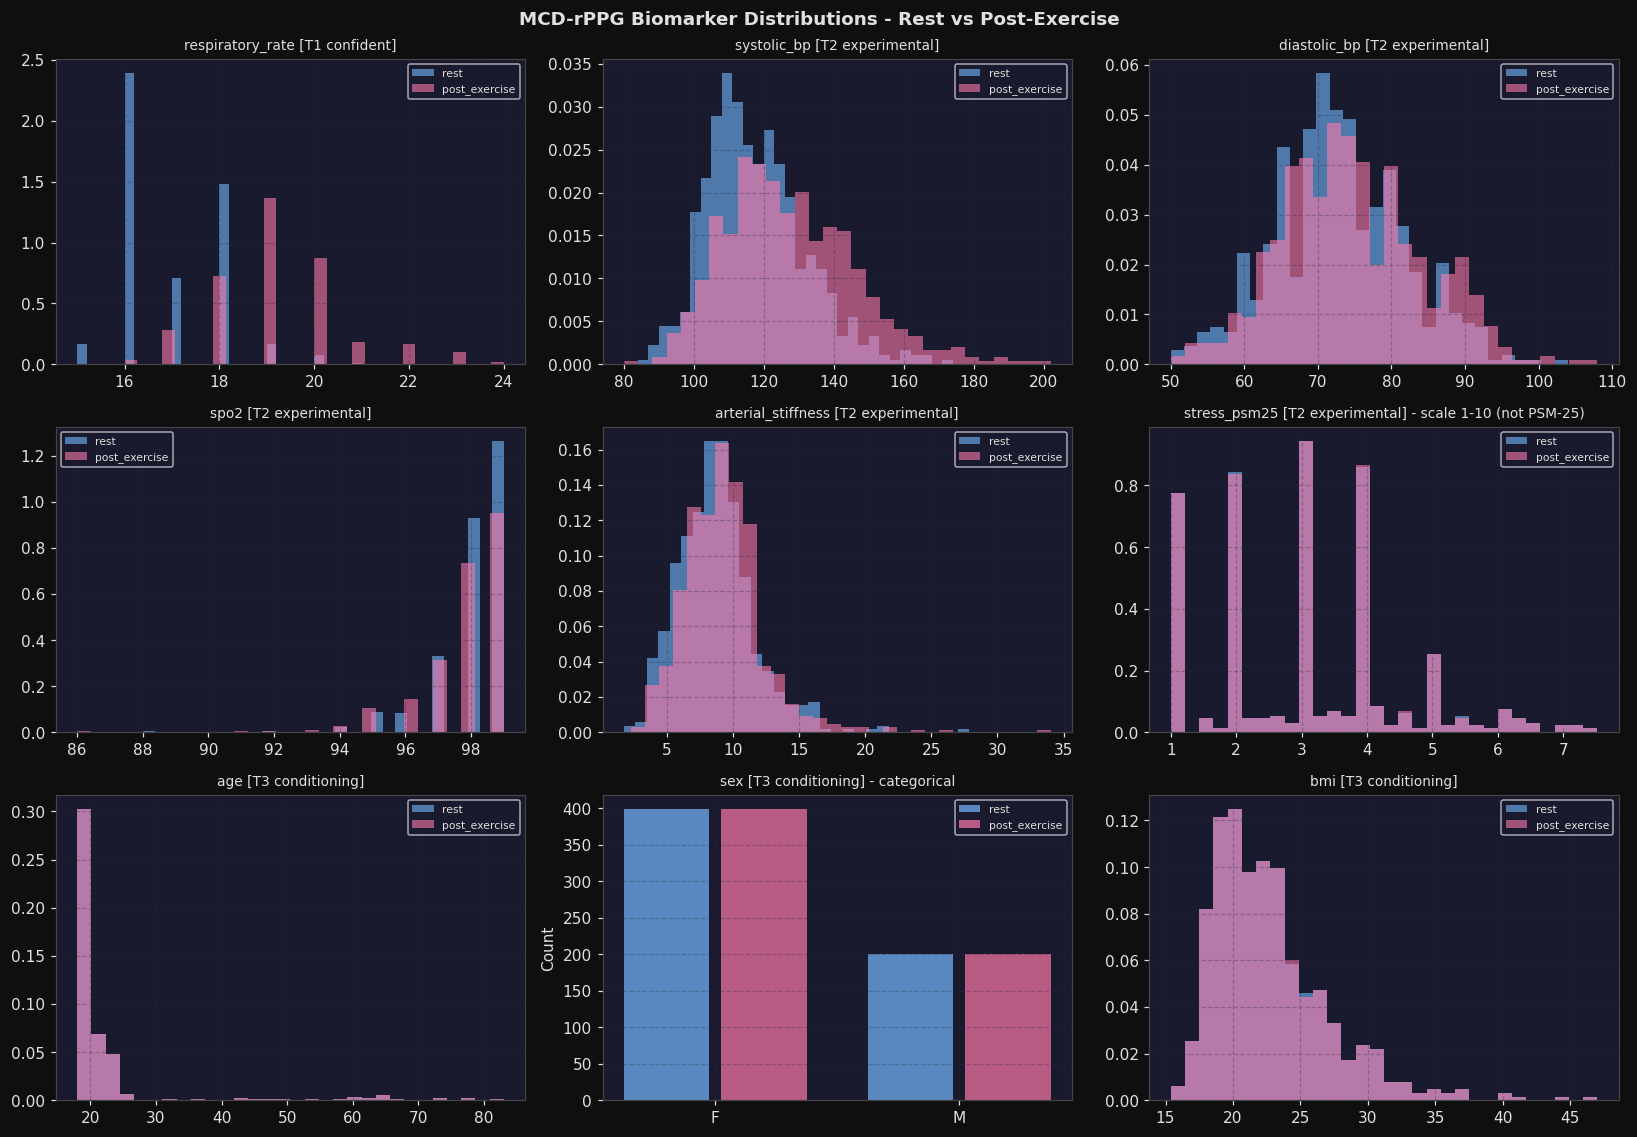

In [5]:
def validate_biomarkers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Check all biomarker values against physiological plausibility ranges.
    Returns a DataFrame of violations with subject_id, biomarker, value, and 
    allowed range.
    """
    violations = []

    for biomarker, (low, high) in BIOMARKER_RANGES.items():
        if biomarker not in df.columns:
            continue
        out_of_range = df[(df[biomarker].notna()) & ((df[biomarker] < low) | (df[biomarker] > high))]
        for _, row in out_of_range.iterrows():
            violations.append({
                "subject_id" : row["subject_id"],
                "state" : row["state"],
                "biomarker" : biomarker,
                "value" : row[biomarker],
                "allowed" : f"{low}-{high}"
            })
            
    return pd.DataFrame(violations)

def plot_biomarker_distributions(df: pd.DataFrame) -> None:
    """
    Plot distributions of all tier 1/2/3 biomarkers split by state.

    Confirmed MCD-rPPG biomarker characteristics:
        sex : categorical string "F"/"M" 
        stress_psm25: range 1-7.52 (ordinal scale, Not full PSM-25 0-100)
        All others : continuous numeric
    """

    plot_bms = [biomarker for biomarker, tier in BIOMARKER_TIERS.items() if tier != "tier_4_not_feasible" and biomarker in df.columns]
    
    n_cols = 3
    n_rows = (len(plot_bms) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
    fig.suptitle("MCD-rPPG Biomarker Distributions - Rest vs Post-Exercise", fontsize=12, fontweight="bold")
    axes = axes.flatten()
    colors = {"before" : "#74b9ff", "after" : "#fd79a8"}

    for idx, biomarker in enumerate(plot_bms):
        ax = axes[idx]
        tier = BIOMARKER_TIERS.get(biomarker, "?")
        tier_short = tier.replace("tier_", "T").replace("_", " ")
        
        if not pd.api.types.is_numeric_dtype(df[biomarker]):
            # Categorical
            for state in STATES:
                subset = df[df["state"] == state][biomarker].dropna()
                counts = subset.value_counts().sort_index()
                x = range(len(counts))
                ax.bar([i + (0.2 if state == "after" else -0.2) for i in x],
                       counts.values, width=0.35, label=STATE_NAMES.get(state, state),
                       color=colors.get(state, "#aaa"), alpha=0.7)
            ax.set_xticks(range(len(counts)))
            ax.set_xticklabels(counts.index.tolist())
            ax.set_ylabel("Count")
            ax.set_title(f"{biomarker} [{tier_short}] - categorical", fontsize=9)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)
            continue

        # Numeric
        for state in STATES:
            subset = df[df["state"] == state][biomarker].dropna()
            if len(subset) > 0:
                ax.hist(subset, bins=30, alpha=0.6, label=STATE_NAMES.get(state, state),
                       color=colors.get(state, "#aaa"), density=True)

        # Annotate stress with its confirmed non-standard scale
        title = f"{biomarker} [{tier_short}]"
        if biomarker == "stress_psm25":
            title += " - scale 1-10 (not PSM-25)"
        ax.set_title(title, fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(len(plot_bms), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/mcd_biomarker_distributions.png",
               bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

# Run validation
if len(df_inventory) > 0 and df_inventory["complete"].sum() > 0:
    df_violations = validate_biomarkers(df_inventory)

    if len(df_violations) == 0:
        print("All biomarker values within physiological ranges")
    else:
        print(f"{len(df_violations)} out-of-range values detected:")
        print(df_violations.to_string(index=False))

    print()
    print("Summary statistics per biomarker and state:")
    feasible_bms = [biomarker for biomarker in BIOMARKER_TIERS if biomarker in df_inventory.columns]
    for biomarker in feasible_bms:
        # Skip categorical biomarkers — sex is 'F'/'M', not numeric
        if not pd.api.types.is_numeric_dtype(df_inventory[biomarker]):
            unique_vals = df_inventory[biomarker].dropna().unique()
            print(f"{biomarker:>25} (categorical): {unique_vals}")
            continue
        
        for state in STATES:
            subset = df_inventory[df_inventory["state"] == state][biomarker].dropna()
            if len(subset) > 0:
                print(f"{biomarker:>25} {STATE_NAMES.get(state, state):<15}: mean={subset.mean():.1f} "
                     f"range {subset.min():.1f}-{subset.max():.1f} n={len(subset)}")

    print()
    plot_biomarker_distributions(df_inventory)
else:
    print("Inventory is empty.")

## 6. Load and Inspect ECG + PPG Signals

**Reference architecture (MCD-rPPG specific):**

- **ECG** (500 Hz, ~30 s strip): used for HRV computation (RMSSD, SDNN, pNN50).
  Too short to drive `hr_continuous` for the full 3-minute video.
- **PPG** (~100 Hz, ~180 s): used as primary reference for `hr_continuous` and
  stored as `reference_signal` in HDF5 (resampled to video FPS).
- `reference_type = "ECG_hrv_PPG_continuous"` documents this hybrid approach.

Inspecting: subject 1020, state after

ECG: 15000 samples at 500.0 Hz = 30.0 s
PPG: 18051 samples at 100.0 Hz = 180.5 s


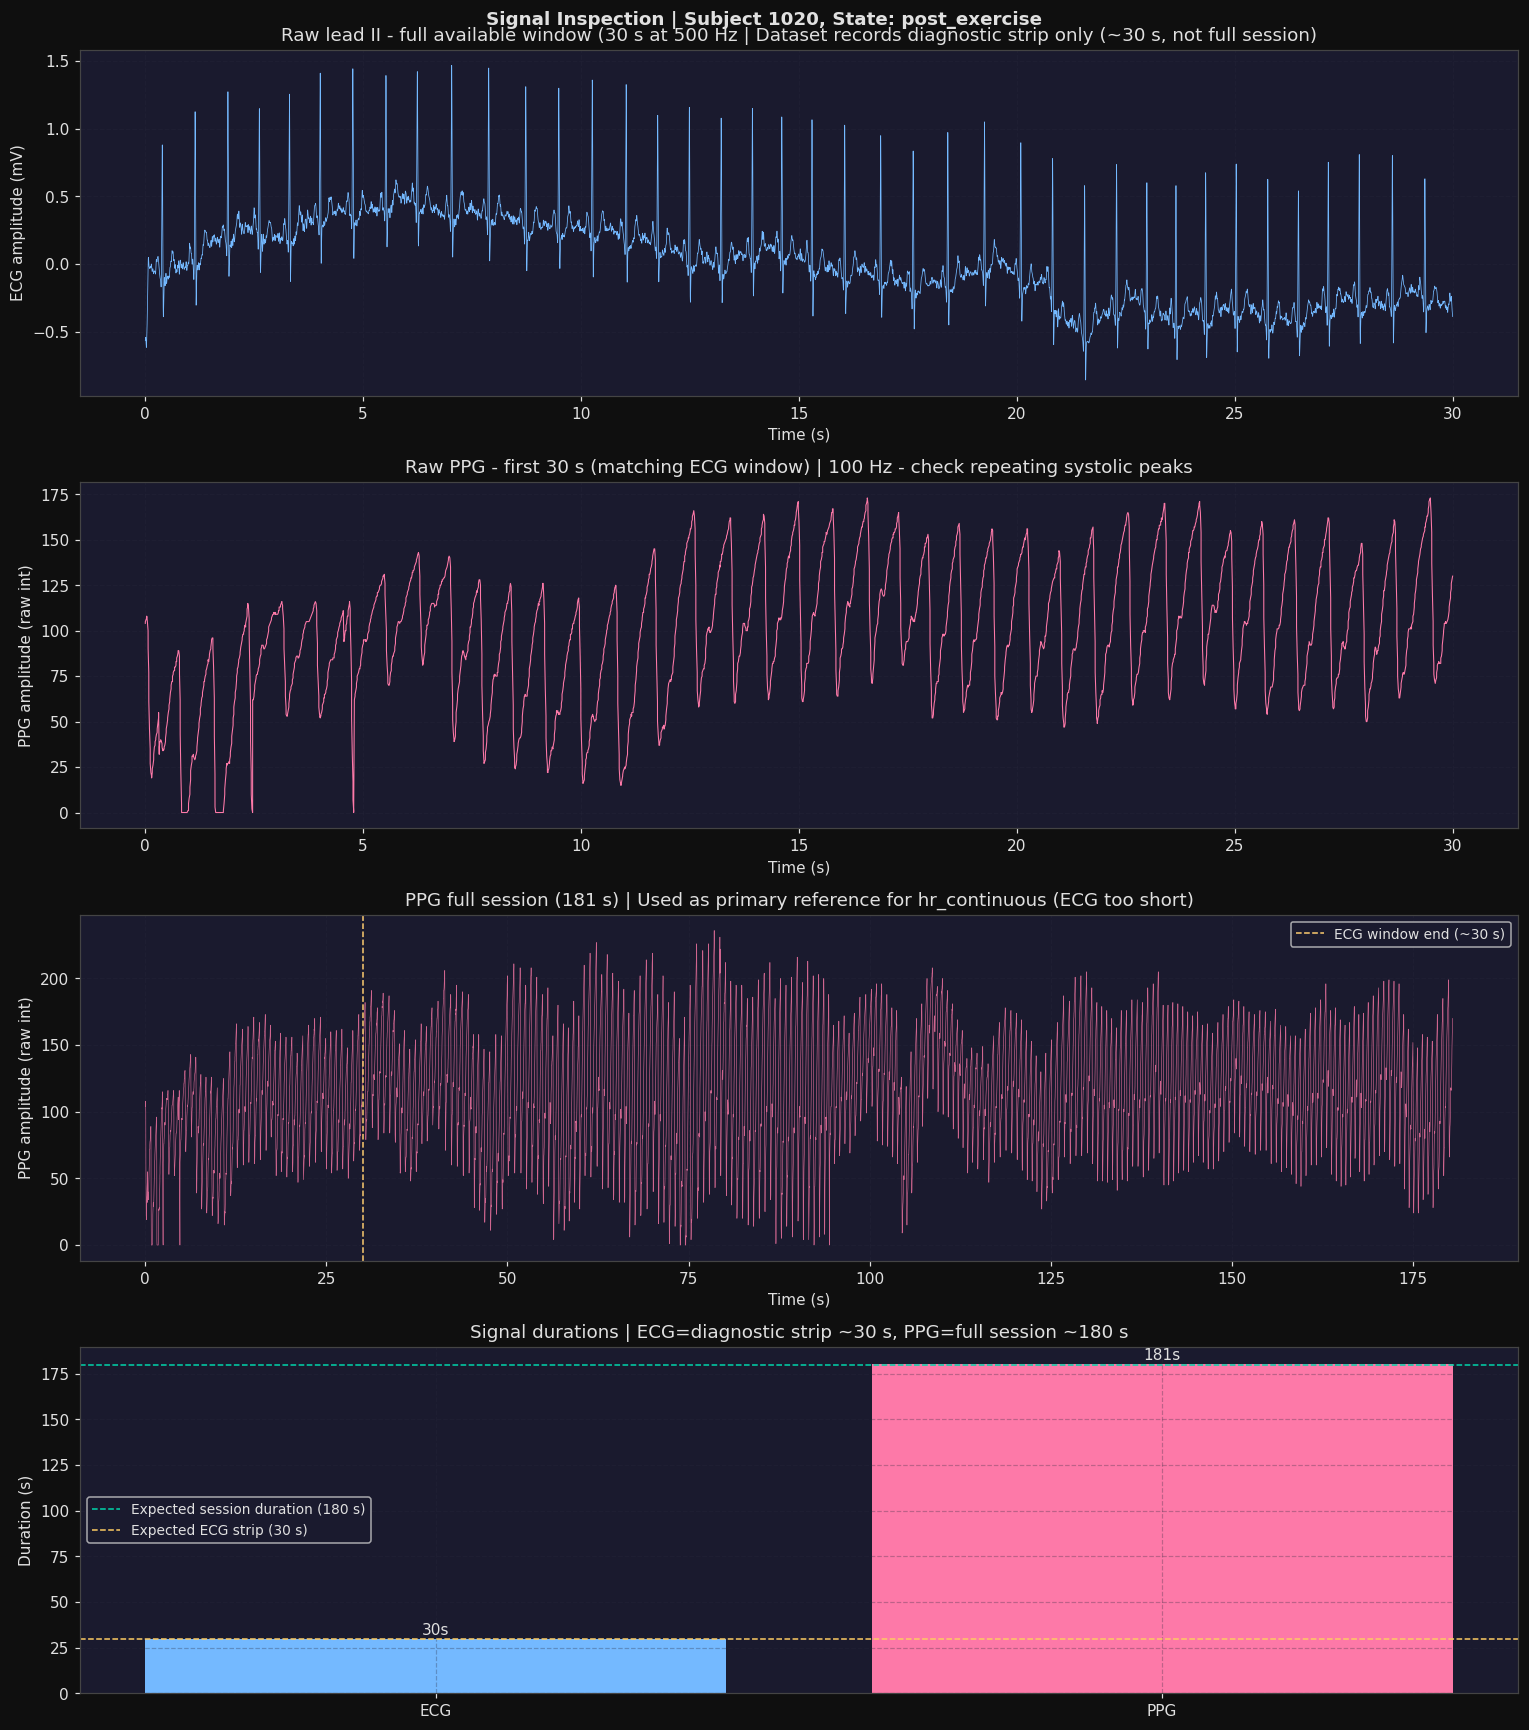

In [6]:
def load_ecg_signal(ecg_path: str) -> dict:
    """
    Load MCD-rPPG ECG from JSON format.

    Confirmed structure:
        frequency : 500 Hz (medical-grade)
        dataX : list of sample indices [0, 1, 2, ...]
        data : list of lead dicts - each {"title" : "I", "values" : [floats]}
        segmentsData : dict of segment annotations (not used)

    Lead II is being used here for R-peak detection - best for QRS morphology for Pan-Tompkins.
    Falls back to lead I if II is not present.
    Values are in millivolts.
    
    Returns:
        ecg_raw : raw ECG waveform
        timestamps : time axis in seconds
        ecg_fs : estimated sampling rate
        "lead" : lead used,
        "all_leads" : list of all leads from ECG
    """
    if not ecg_path or not os.path.exists(ecg_path):
        return None

    try:
        with open(ecg_path, "r") as file:
            ecg_json = json.load(file)
    except (json.JSONDecodeError, OSError) as error:
        print(f"WARNING: Corrupted ECG JSON at {ecg_path} - {error}")
        print(f"Falling back to PPG-only mode for this recording.")
        return None
        
    ecg_fs = float(ecg_json.get("frequency", ECG_FS))

    # Sanity check - dataset paper states 100 Hz
    if not (200.0 < ecg_fs < 1000.0):
        print(f"WARNING: ECG frequency={ecg_fs} Hz is unusual - check JSON")

    # Extract best lead for R-peak detection
    # Lead II has the tallest R-waves in most subjects -> preferred for Pan-Tompkins
    leads = {lead["title"] : np.array(lead["values"], dtype=np.float32) for lead in ecg_json["data"]}
    
    if "II" in leads:
        ecg_raw, lead_used = leads["II"], "II"
    elif "I" in leads:
        ecg_raw, lead_used = leads["I"], "I"
    else:
        # Fallback to first available lead
        lead_used = list(leads.keys())[0]
        ecg_raw = leads[lead_used]
        print(f"WARNING: leads II and I not found, using lead {lead_used}")
        
    timestamps = np.arange(len(ecg_raw)) / ecg_fs

    return {
        "ecg_raw" : ecg_raw,
        "timestamps" : timestamps,
        "ecg_fs" : ecg_fs,
        "lead" : lead_used,
        "all_leads" : list(leads.keys()),
    }


def load_ppg_signal(ppg_path: str) -> dict:
    """
    Load MCD-rPPG PPG from .PW format.

    Confirmed structure from dataset exploration:
        Integer value datetime with microseconds
        104             2023-11-13 14:18:09.873186
        105             2023-11-13 14:18:09.874189
        ...

    Two withespace-separated columns.
    Column 0: integer PPG amplitude.
    Columns 1+2: date and time (split by whitespace - must rejoin).
    Sampling rate is estimated from the inter-sample timestamps.
    """
    if not ppg_path or not os.path.exists(ppg_path):
        return None
    try:
        df = pd.read_csv(ppg_path, sep=r"\s+", header=None, dtype=str)
        # Column 0: signal, columns 1 and 2: date and time halves
        ppg_raw = df.iloc[:, 0].astype(np.float32).values
        datetime_str = df.iloc[:, 1] + " " + df.iloc[:, 2]
        timestamps_dt = pd.to_datetime(datetime_str, format="mixed")
        timestamps = (timestamps_dt - timestamps_dt.iloc[0]).dt.total_seconds().values.astype(np.float64)
    except Exception as error:
        print(f"WARNING: Corrupted PPG file at {ppg_path} - {error}")
        print(f"Falling back to ECG-only mode for this recording.")
        return None 
        
    dt_s = np.diff(timestamps).mean() if len(timestamps) > 1 else 1.0 / PPG_FS
    ppg_fs = 1.0 / dt_s if dt_s > 0 else PPG_FS

    # Sanity-check - PPG should be close to 100 Hz
    if not (50.0 < ppg_fs < 200.0):
        print(f"WARNING: Estimated PPG fs={ppg_fs:.1f} Hz is unusual - check .PW file")

    return {
        "ppg_raw" : ppg_raw,
        "timestamps" : timestamps,
        "ppg_fs" : float(ppg_fs)
    }

def inspect_signals(ecg_data: dict, ppg_data: dict, subject_id: int, state: str) -> None:
    """
    Visual inspection of ECG and PPG for one recording.

    Confirmed MCD-rPPG dataset characteristics:
    ECG : ~30 s at 500 Hz (diagnostic strip, not continuous)
        Contains multiple leads - lead II used for R-peak detection
    PPG : ~180 s at ~100 Hz (full session, finger probe)
        Single amplitude column with datetime timestamps in .PW format

    Four panels:
        1. Raw ECG lead II - full 30 s 
        2. Raw PPG - first 30 s (match ECG window for visual comparison)
        3. PPG full duration - confirm 180 s coverage
        4. Signal duration bar chart - ECG ~30 s, PPG ~180 
    """
    fig, axes = plt.subplots(4, 1, figsize=(14, 16))
    fig.suptitle(f"Signal Inspection | Subject {subject_id}, State: {STATE_NAMES.get(state, state)}", 
                 fontsize=12, fontweight="bold")

    # Panel 1: ECG - show full available window (expect ~30s)
    if ecg_data is not None:
        ecg = ecg_data["ecg_raw"]
        fs = ecg_data["ecg_fs"]
        ts = ecg_data["timestamps"]
        lead = ecg_data.get("lead", "?")
        ax = axes[0]
        ax.plot(ts, ecg, color="#74b9ff", lw=0.5)
        ax.set_ylabel("ECG amplitude (mV)")
        ax.set_xlabel("Time (s)")
        ax.set_title(f"Raw lead {lead} - full available window ({len(ecg)/fs:.0f} s at {fs:.0f} Hz | Dataset records diagnostic strip only (~30 s, not full session)")
        ax.grid(True, alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, "ECG not loaded", ha="center", va="center",
                     transform=axes[0].transAxes, color="#e0e0e0")

    # Panel 2: PPG first 30 s - matches ECG window for comparison
    if ppg_data:
        ppg = ppg_data["ppg_raw"]
        fs = ppg_data["ppg_fs"]
        ts = ppg_data["timestamps"]
        n30 = int(fs * 30)
        ax = axes[1]
        ax.plot(ts[:n30], ppg[:n30], color="#fd79a8", lw=0.7)
        ax.set_ylabel("PPG amplitude (raw int)")
        ax.set_xlabel("Time (s)")
        ax.set_title(f"Raw PPG - first 30 s (matching ECG window) | {fs:.0f} Hz - check repeating systolic peaks")
        ax.grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, "PPG not loaded", ha="center", va="center",
                     transform=axes[1].transAxes, color="#e0e0e0")
        
    # Panel 3: PPG full session - confirm 180 s coverage
    if ppg_data:
        ax = axes[2]
        ax.plot(ts, ppg, color="#fd79a8", lw=0.4, alpha=0.8)
        ax.set_ylabel("PPG amplitude (raw int)")
        ax.set_xlabel("Time (s)")
        ax.set_title(f"PPG full session ({len(ppg)/fs:.0f} s) | Used as primary reference for hr_continuous (ECG too short)")
        ax.axvline(30, color="#fdcb6e", ls="--", lw=1, label="ECG window end (~30 s)")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, "PPG not loaded", ha="center", va="center",
                     transform=axes[2].transAxes, color="#e0e0e0")

    # Panel 4: Duration bar chart
    ax = axes[3]
    durations = {} 
    if ecg_data is not None:
        durations["ECG"] = len(ecg_data["ecg_raw"]) / ecg_data["ecg_fs"]
    if ppg_data:
        durations["PPG"] = len(ppg_data["ppg_raw"]) / ppg_data["ppg_fs"]

    bar_colors = {"ECG": "#74b9ff", "PPG": "#fd79a8"}
    bars = ax.bar(list(durations.keys()), list(durations.values()), color=[bar_colors.get(k, "#aaa") for k in durations])
    ax.axhline(180, color="#00d4aa", ls="--", lw=1, label="Expected session duration (180 s)")
    ax.axhline(30, color="#fdcb63", ls="--", lw=1, label="Expected ECG strip (30 s)")
    ax.set_ylabel("Duration (s)")
    ax.set_title("Signal durations | ECG=diagnostic strip ~30 s, PPG=full session ~180 s")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    for bar, (name, value)in zip(bars, durations.items()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, f"{value:.0f}s",
               ha="center", fontsize=10, color="#e0e0e0")


    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/mcd_signal_inspect_s{subject_id:04d}_{state}.png",
               bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

# Run of first complete recording 
first = df_inventory[df_inventory["complete"]].iloc[0]
print(f"Inspecting: subject {first.subject_id}, state {first.state}")
print()

ecg_demo = load_ecg_signal(first["ecg_path"]) if first["ecg_path"] else None
ppg_demo = load_ppg_signal(first["ppg_path"]) if first["ppg_path"] else None


if ecg_demo:
    print(f"ECG: {len(ecg_demo['ecg_raw'])} samples at {ecg_demo['ecg_fs']:.1f} Hz = {len(ecg_demo['ecg_raw'])/ecg_demo['ecg_fs']:.1f} s")
else:
    print("ECG file not found - will use PPG as reference")

if ppg_demo:
    print(f"PPG: {len(ppg_demo['ppg_raw'])} samples at {ppg_demo['ppg_fs']:.1f} Hz = {len(ppg_demo['ppg_raw'])/ppg_demo['ppg_fs']:.1f} s")
else:
    print("PPG file not found")

if ecg_demo or ppg_demo:
    inspect_signals(ecg_demo, ppg_demo, first["subject_id"], first["state"])

## 7. Signal Processing — Filter, Peak Detection, HRV

ECG pipeline: `bandpass 0.5–40 Hz` -> `nk.ecg_clean()` -> `nk.ecg_peaks()` -> RR -> HRV.  
PPG pipeline: `bandpass 0.5–8 Hz` -> `nk.ppg_clean()` -> `nk.ppg_peaks()`.

`build_hr_continuous` accepts a `source_fs` parameter so it works correctly whether
driven by ECG peaks (500 Hz sample space) or PPG peaks (~100 Hz sample space).
In this notebook PPG peaks drive `hr_continuous` because ECG covers only 30 s.

In [7]:
def bandpass_filter(signal: np.ndarray, fs: float, low: float, high: float, order: int = 2) -> np.ndarray:
    """
    Zero-phase Butterworth bandpass filter.
    """
    nyq = fs / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal).astype(np.float32)

def resample_to_fps(signal: np.ndarray, original_fs: float, target_fps: float) -> np.ndarray:
    """
    Resample physiological signal to video FPS via linear interpolation.
    """
    n_original = len(signal)
    n_target = int(n_original * target_fps / original_fs)
    return np.interp(np.linspace(0, 1, n_target), np.linspace(0, 1, n_original), signal).astype(np.float32)


def detect_ecg_peaks(ecg_raw: np.ndarray, ecg_fs: float) -> tuple:
    """
    Detect R-peaks from ECG.
    
    Pipeline: bandpass -> nk.ecg_clean() -> nk.ecg_peaks()
    Returns:
        peak_indices : R-peak sample indices
        rr_ms : RR intervals in milliseconds
        hr_mean : mean HR in BPM
        ecg_filtered : bandpass-filtered ECG (from HDF5 storage and SQI)
    """
    ecg_filtered = bandpass_filter(ecg_raw, ecg_fs, ECG_BP_LOW, ECG_BP_HIGH)
    ecg_clean = nk.ecg_clean(ecg_filtered, sampling_rate=int(ecg_fs))

    peak_dict, _ = nk.ecg_peaks(ecg_clean, sampling_rate=int(ecg_fs))
    peak_indices = np.where(peak_dict["ECG_R_Peaks"] == 1)[0]
    
    if len(peak_indices) < 3:
        return peak_indices, np.array([]), float("nan"), ecg_filtered

    rr_ms = np.diff(peak_indices) / ecg_fs * 1000.0
    hr_mean = float(60000.0 / rr_ms.mean())

    return peak_indices, rr_ms, hr_mean, ecg_filtered


def detect_ppg_peaks(ppg_raw: np.ndarray, ppg_fs: float) -> tuple:
    """
    Detect systolic peaks from PPG.
    Used here for cross-validation against ECG HR, not as primary reference.
    """
    ppg_filtered = bandpass_filter(ppg_raw, ppg_fs, PPG_BP_LOW, PPG_BP_HIGH)
    ppg_clean = nk.ppg_clean(ppg_filtered, sampling_rate=int(ppg_fs))
    peak_dict, _ = nk.ppg_peaks(ppg_clean, sampling_rate=int(ppg_fs))
    peak_indices = np.where(peak_dict["PPG_Peaks"] == 1)[0]

    if len(peak_indices) < 3:
        return peak_indices, np.array([]), float("nan")

    rr_ms = np.diff(peak_indices) / ppg_fs * 1000.0
    hr_mean = float(60000.0 / rr_ms.mean())

    return peak_indices, rr_ms, hr_mean

def compute_hrv_features(rr_ms: np.ndarray) -> dict:
    """
    Time-domain HRV from RR intervals.
    """
    nan_result = {
        "mean_rr_ms" : float("nan"),
        "sdnn_ms" : float("nan"),
        "rmssd_ms" : float("nan"),
        "pnn50_pct" : float("nan"),
        "hr_mean_bpm" : float("nan"),
        "hr_min_bpm" : float("nan"),
        "hr_max_bpm" : float("nan")
    }

    if len(rr_ms) < 3:
        return nan_result

    rr_clean = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]

    if len(rr_clean) < 3:
        return nan_result

    successive_diffs = np.diff(rr_clean)

    return {
        "mean_rr_ms" : float(rr_clean.mean()),
        "sdnn_ms" : float(rr_clean.std()),
        "rmssd_ms" : float(np.sqrt(np.mean(successive_diffs ** 2))),
        "pnn50_pct" : float((np.abs(successive_diffs) > 50).mean() * 100),
        "hr_mean_bpm" : float(60000.0 / rr_clean.mean()),
        "hr_min_bpm" : float(60000.0 / rr_clean.max()),
        "hr_max_bpm" : float(60000.0 / rr_clean.min())
    }

def build_hr_continuous(peak_indices: np.ndarray, rr_ms: np.ndarray, source_fs: float, n_video_frames: int, target_fps: float) -> np.ndarray:
    """
    Build continuous HR array at video frame rate from physiological peak positions.
    Works for both ECG peaks (source_fs=ECG_FS) and PPG peaks (source_fs=PPG_FS).
    In this notebook PPG peaks are used (full 180 s coverage).
    """
    hr_continuous = np.full(n_video_frames, np.nan, dtype=np.float32)

    if len(peak_indices) < 2 or len(rr_ms) == 0:
        return hr_continuous

    # Convert each peak 
    for i, idx in enumerate(peak_indices[:-1]):
        frame_idx = int(idx / source_fs * target_fps)
        if 0 <= frame_idx < n_video_frames:
            hr_continuous[frame_idx] = 60000.0 / rr_ms[i]

    # Forward-fill between peaks
    last_hr = np.nan
    for i in range(n_video_frames):
        if not np.isnan(hr_continuous[i]):
            last_hr = hr_continuous[i]
        elif not np.isnan(last_hr):
            hr_continuous[i] = last_hr
    
    return hr_continuous


# Demo on first complete recording
if ecg_demo:
    ecg_raw = ecg_demo["ecg_raw"]
    ecg_fs = ecg_demo["ecg_fs"]

    peak_indices_demo, rr_ms_demo, hr_mean_demo, ecg_filt_demo = detect_ecg_peaks(ecg_raw, ecg_fs)
    hrv_demo = compute_hrv_features(rr_ms_demo)

    print(f"ECG-derived HR : {hr_mean_demo:.1f} BPM")
    print(f"RMSSD : {hrv_demo['rmssd_ms']:.1f} ms")
    print(f"SDNN : {hrv_demo['sdnn_ms']:.1f} ms")
    print(f"pNN50 : {hrv_demo['pnn50_pct']:.1f} %")

    if ppg_demo:
        ppg_raw = ppg_demo["ppg_raw"]
        ppg_fs = ppg_demo["ppg_fs"]
        _, _, hr_ppg = detect_ppg_peaks(ppg_raw, ppg_fs)

        print()
        print(f"PPG-derived HR : {hr_ppg:.1f} BPM")
        print(f"ECG vs PPG diff : {abs(hr_mean_demo - hr_ppg):.1f} BPM")

        if abs(hr_mean_demo - hr_ppg) < 10:
            print("Good agreement between ECG and PPG HR")
        else:
            print("Large discrepancy - check signal quality visually")
    else:
        print("ECG not loaded.") 

ECG-derived HR : 80.8 BPM
RMSSD : 42.0 ms
SDNN : 48.0 ms
pNN50 : 21.1 %

PPG-derived HR : 81.0 BPM
ECG vs PPG diff : 0.3 BPM
Good agreement between ECG and PPG HR


## 8. Signal Quality Index (SQI)


In [8]:
def compute_ecg_sqi(rr_ms: np.ndarray) -> float:
    """
    ECG Signal Quality Index - RR interval regularity.
    Score = 1 - min(CV, 1.0) where CV = std(RR)/mean(RR)
    """
    if len(rr_ms) < 3:
        return float("nan")

    rr_clean = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr_clean) < 3:
        return float("nan")

    cv = rr_clean.std() / (rr_clean.mean() + 1e-8)
    return float(1.0 - min(cv, 1.0))


def compute_rppg_sqi(rppg_signal: np.ndarray, hr_bpm: float, fs: float) -> float:
    """
    rPPG SQI - autocorrelation at expected HR lag.
    """
    if hr_bpm <= 0 or np.isnan(hr_bpm):
        return float("nan")

    beat_period = int(round(fs * 60.0 / hr_bpm))

    if beat_period >= len(rppg_signal):
        return float("nan")

    s = rppg_signal - rppg_signal.mean()
    denom = np.dot(s, s)
    if denom < 1e-10:
        return 0.0
    numer = np.dot(s[:-beat_period], s[beat_period:])
    return float(max(0.0, min(numer / denom, 1.0)))

# Demo SQI
if "rr_ms_demo" in dir() and len(rr_ms_demo) > 0:
    ecg_sqi_demo = compute_ecg_sqi(rr_ms_demo)
    print(f"ECG SQI : {ecg_sqi_demo:.3f} (threshold: {ECG_SQI_THRESHOLD})")
    if ecg_sqi_demo >= ECG_SQI_THRESHOLD:
        print("ECG quality acceptable")
    else:
        print("ECG quality below threshold")
else:
    print("Run Cell 7 first to compute rr_ms_demo.")
print()

ECG SQI : 0.935 (threshold: 0.5)
ECG quality acceptable



## 9. rPPG Extraction (Video -> Signal)

Identical pipeline to UBF-rPPG and UBFC-Phys: `COLOR_BGR2RGB` -> MediaPipe face landmarker -> ROI spatial mean -> POS -> bandpass -> z-score.

In [9]:
# Download MediaPipe face landmarker model if not present
MODEL_PATH = "./face_landmarker.task"
if not os.path.exists(MODEL_PATH):
    print("Downloading MediaPipe face landmarker model...")
    url = ("https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task")
    urllib.request.urlretrieve(url, MODEL_PATH)
    print("Downloaded.")
else:
    print("Face landmarker model already present.")

def get_roi_mask(landmarks, frame_shape: tuple, landmark_indices: list) -> np.ndarray:
    """Build binary polygon mask for one ROI."""
    h, w = frame_shape[:2]
    pts = np.array([[int(landmarks[idx].x * w), int(landmarks[idx].y * h)] for idx in landmark_indices], dtype=np.int32)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def extract_roi_signals(video_path: str, roi_configs: dict, max_frames: int = None) -> dict:
    """
    Etract spatially-averaged RGB from facial ROIs Returns actual fps.
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    roi_sigs = {name: [] for name in roi_configs}
    n_frames = 0
    no_face_ct = 0

    base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
    options = mp_vision.FaceLandmarkerOptions(
        base_options=base_options,
        running_mode=mp_vision.RunningMode.VIDEO,
        num_faces=1
    )

    with mp_vision.FaceLandmarker.create_from_options(options) as landmarker:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if max_frames and n_frames >= max_frames:
                break

            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            ts_ms = int((n_frames / fps) * 1000)
            result = landmarker.detect_for_video(mp_image, ts_ms)

            if result.face_landmarks:
                lm = result.face_landmarks[0]
                for name, indices in roi_configs.items():
                    mask = get_roi_mask(lm, rgb_frame.shape, indices)
                    if mask.sum() > 0:
                        r = rgb_frame[:, :, 0][mask == 1].mean()
                        g = rgb_frame[:, :, 1][mask == 1].mean()
                        b = rgb_frame[:, :, 2][mask == 1].mean()
                        roi_sigs[name].append(np.array([r, g, b], dtype=np.float32))
                    else:
                        fallback = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                        roi_sigs[name].append(fallback)
            else:
                no_face_ct += 1
                for name in roi_configs:
                    fallback = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                    roi_sigs[name].append(fallback)

            n_frames += 1

    cap.release()

    result_dict = {name: np.array(values) for name, values in roi_sigs.items()}
    result_dict["__fps__"] = fps
    result_dict["__n_frames__"]= n_frames
    result_dict["__no_face_pct__"] = round(100 * no_face_ct / max(n_frames, 1), 1)
    return result_dict

def extract_pos(clip_roi: dict, fps: float) -> np.ndarray:
    """POS method averaged across ROIs. Uses actual fps for bandpass"""
    P = np.array([[0, 1, -1], [-2, 1, 1]], dtype=np.float64)
    roi_names = [k for k in clip_roi if not k.startswith("__")]
    signals = []

    for name in roi_names:
        C = clip_roi[name].astype(np.float64)
        Cn = C / (C.mean(axis=0) + 1e-8)
        S = P @ Cn.T
        h = S[0] + (S[0].std() / (S[1].std() + 1e-8)) * S[1]
        signals.append(h)

    combined = np.mean(signals, axis=0)
    filtered = bandpass_filter(combined, fps, RPPG_BP_LOW, RPPG_BP_HIGH)
    mu, sigma = filtered.mean(), filtered.std() + 1e-8
    return ((filtered - mu) / sigma).astype(np.float32)

print("rPPG extraction functions defined.")
                        

Face landmarker model already present.
rPPG extraction functions defined.


## 10. Full Pipeline - Single Recording 


Skip logic:
- `ecg_too_short` - ECG < 10 s (unexpected)
- `flat_ecg_signal` - ECG amplitude < 0.05 mV (sensor issue)
- `ecg_sqi_low` - RR irregularity
- `no_ppg_signal` - PPG missing (cannot build hr_continuous)
- `flat_ppg_signal` - PPG amplitude < 1 ADC unit
- `implausible_hr` - HR outside 40–200 BPM
- `ecg_ppg_hr_mismatch` - ECG and PPG HR differ > 10 BPM
- `no_face` - >20% frames without face detection
- `rppg_sqi_low` - rPPG lacks cardiac periodicity


In [10]:
def process_single_recording(row: pd.Series, max_frames: int = None) -> tuple:
    """
    Full preprocessing pipeline for one MCD-rPPG recording.

    Confirmed dataset characteristics that drive pipeline design:
        ECG : ~30 s diagnostic strip at 500 Hz, lead II used for R-peak detection.
              High quality for HRV computation but too shor for hr_continuous.
        PPG : ~180 s at ~100 Hz, covers full session.
              Used as primary reference for hr_continuous and reference_signal.

    Reference strategy (differs from ECG-Fitness where ECG covers full session):
        hr_mean, rmssd_ms, sdnn_ms, pnn50_pct -> ECG-derived (30 s window, high quality)
        hr_continuous [T frames] -> PPG-derived (full 180 s coverage)
        reference_signal [T frames] -> PPG resampled to FPS
        reference_type  -> "ECG_hrv_PPG_continuous"
        
    Args:
        row : one row from df_inventory (includes paths + biomarkers)
        max_frames : limit for quick testing (None = full 3-minute video)
        
    Returns:
        (result_dict, reson_string)
        result_dict is None if the recording was skipped.
    """
    subject_id = int(row["subject_id"])
    state = row["state"]
    label = f"s{subject_id:04d}/{state}"

    # Step 1: Load reference signals
    ecg_data = load_ecg_signal(row["ecg_path"]) if row["ecg_path"] else None
    ppg_data = load_ppg_signal(row["ppg_path"]) if row["ppg_path"] else None

    if ecg_data is None and ppg_data is None:
        print(f"SKIP {label}: no reference signal found")
        return None, "no_reference_signal"


    # Step 2: ECG processing - HRV only (30 s window)
    ecg_sqi = float("nan")
    rr_ms = np.array([])
    hr_mean_ecg = float("nan")

    
    if ecg_data is not None:
        ecg_raw = ecg_data["ecg_raw"]
        ecg_fs = ecg_data["ecg_fs"]

        ecg_duration_s = len(ecg_raw) / ecg_fs
        if ecg_duration_s < 10.0:
            print(f"SKIP {label}: ECG too short ({ecg_duration_s:.1f} s)")
            return None, f"ecg_too_short ({ecg_duration_s:.1f} s)"
            
        if ecg_raw.max() - ecg_raw.min() < 0.05:
            # mV scale - flat threshold much lower than ADC-scale dataset
            print(f"SKIP {label}: flat ECG signal")
            return None, "flat_ecg_signal"

        _, rr_ms, hr_mean_ecg, _ = detect_ecg_peaks(ecg_raw, ecg_fs)

        if not np.isnan(hr_mean_ecg):
            ecg_sqi = compute_ecg_sqi(rr_ms)
            if ecg_sqi < ECG_SQI_THRESHOLD:
                print(f"SKIP {label}: ECG SQI too low ({ecg_sqi:.3f})")
                return None, f"ecg_sqi_low ({ecg_sqi:.3f})"

    hrv = compute_hrv_features(rr_ms)

    # Step 3: PPG processing - primary reference for hr_continuous
    # ECG covers only ~30 s. PPG covers ~180 s session.
    # PPG drives hr_continuous and cross-validates ECG HR.
    if ppg_data is None:
        print(f"SKIP {label}: no PPG - cannot build hr_continuous")
        return None, "no_ppg_signal"
    
    ppg_raw = ppg_data["ppg_raw"]
    ppg_fs = ppg_data["ppg_fs"]

    if ppg_raw.max() - ppg_raw.min() < 1.0:
            # Integer amplitude scale - flat threshold appropriate for .PW format
            print(f"SKIP {label}: flat PPG signal")
            return None, "flat_ppg_signal"

    ppg_peak_indices, rr_ms_ppg, hr_mean_ppg = detect_ppg_peaks(ppg_raw, ppg_fs)

    if np.isnan(hr_mean_ppg) or hr_mean_ppg < HR_MIN or hr_mean_ppg > HR_MAX:
        print(f"SKIP {label}: implausible PPG HR ({hr_mean_ppg:.1f} BPM)")
        return None, f"implausible_hr ({hr_mean_ppg:.1f} BPM)"
        
    # Cross-check ECG vs PPG HR if ECG available (tolerance 10 BPM)
    if not np.isnan(hr_mean_ecg) and not np.isnan(hr_mean_ppg):
        hr_diff = abs(hr_mean_ecg - hr_mean_ppg)
        if hr_diff > 10:
            print(f"SKIP {label}: ECG/PPG HR mismatch (ECG={hr_mean_ecg:.1f} PPG={hr_mean_ppg:.1f} diff={hr_diff:.1f})")
            return None, f"ecg_ppg_hr_mismatch ({hr_diff:.1f} BPM)"

    # Use PPG HR as primary hr_mean (full session coverage)
    hr_mean = hr_mean_ppg
    
    # Step 4: Resample PPG to video FPS
    ppg_resampled = resample_to_fps(ppg_raw, ppg_fs, FPS)

    # Step 5: Extract rPPG from video
    roi_data = extract_roi_signals(row["video_path"], ROI_CONFIGS, max_frames=max_frames)
    n_frames = roi_data["__n_frames__"]
    no_face = roi_data["__no_face_pct__"]
    actual_fps = roi_data["__fps__"]
    
    if no_face > 20.0:
        print(f"SKIP {label}: too many frames without face (face{no_face:.1f}%)")
        return None, f"no_face ({no_face:.1f}%)"

    rppg_signal = extract_pos(roi_data, actual_fps)

    roi_names = [k for k in roi_data if not k.startswith("__")]
    roi_rgb = np.stack([roi_data[name] for name in roi_names], axis=1).astype(np.float32)

    # Step 6: rPPG SQI
    rppg_sqi = compute_rppg_sqi(rppg_signal, hr_mean, actual_fps)
    if rppg_sqi < RPPG_SQI_THRESHOLD:
        print(f"SKIP {label}: rPPG SQI to low({rppg_sqi:.3f})")
        return None, f"rppg_sqi_low ({rppg_sqi:.3f})"

    # Step 7: Build continuous HR from PPG
    # PPG peak indices are in PPG sample space - convert to video frame space
    hr_continuous = build_hr_continuous(ppg_peak_indices, rr_ms_ppg, ppg_fs, n_frames, actual_fps)

    # Step 8: Align all signals to shortest common length
    T = min(n_frames, len(rppg_signal), len(hr_continuous), len(ppg_resampled), roi_rgb.shape[0])
    
    rppg_signal = rppg_signal[:T]
    hr_continuous = hr_continuous[:T]
    roi_rgb = roi_rgb[:T]
    reference_signal = ppg_resampled[:T]

    # Step 9: Collect and validate biomarkers
    biomarkers  = {}
    biomarker_flags = {} # True = value is within plausible range

    for biomarker in BIOMARKER_TIERS.keys():
        raw = row.get(biomarker, np.nan)
        try:
            value = float(raw)
        except (ValueError, TypeError):
            value = raw # keep string (e.g. sex = "F"/"M")
            
        biomarkers[biomarker] = value

        if biomarker in BIOMARKER_RANGES and isinstance(value, float) and not np.isnan(value):
            low, high = BIOMARKER_RANGES[biomarker]
            biomarker_flags[f"{biomarker}_valid"] = (low <= value <= high)
        else:
            biomarker_flags[f"{biomarker}_valid"] = np.nan
            
    # rr_intervals stored from ECG if available, else PPG
    rr_intervals = rr_ms.astype(np.float32) if len(rr_ms) > 0 else rr_ms_ppg.astype(np.float32)

    print(f"{label} T={T} HR={hr_mean:.1f} ECG_SQI={ecg_sqi:.2f}  rPPG_SQI={rppg_sqi:.2f} no_face={no_face:.1f}%  fps={actual_fps:.2f}")
    
    result = {
        # Signals
        "rppg_signal" : rppg_signal,
        "roi_rgb" : roi_rgb,
        "reference_signal" : reference_signal,
        "hr_continuous" : hr_continuous,
        "rr_intervals" : rr_intervals,
        # HRV - ECG-derived where available (higher quality, 30 s window)
        "hr_mean" : float(hr_mean),
        "rmssd_ms" : hrv["rmssd_ms"],
        "sdnn_ms" : hrv["sdnn_ms"],
        "pnn50_pct" : hrv["pnn50_pct"],
        # Biomarkers - all 13
        **biomarkers,
        **biomarker_flags,
        # Metadata
        "subject_id" : subject_id,
        "activity_id" : state,
        "activity_name" : STATE_NAMES.get(state, state),
        "camera" : CAMERA_SELECT,
        "dataset" : DATASET_NAME,
        "reference_type" :  "ECG_hrv_PPG_continuous",
        "n_frames" : T,
        "fps" : actual_fps,
        "ecg_sqi" : float(ecg_sqi) if not np.isnan(ecg_sqi) else -1.0,
        "rppg_sqi" : float(rppg_sqi),
        "no_face_pct" : float(no_face),
    }
    return result, "ok"

# Test on first complete recording - 300 frames (~10s)
print("Running single-recording pipeline test (300 frames)...")
first = df_inventory[df_inventory["complete"]].iloc[0]
demo_result, demo_reason = process_single_recording(first, max_frames=300)

if demo_result is not None:
    print()
    print("Signals:")
    for key in ["rppg_signal", "roi_rgb", "reference_signal", "hr_continuous", "rr_intervals"]:
        if key in demo_result and hasattr(demo_result[key], "shape"):
            print(f"{key:<20}: {demo_result[key].shape}")

    print()
    print("Scalars:")
    for key in ["hr_mean", "rmssd_ms", "rppg_sqi", "ecg_sqi", "reference_type"]:
        value = demo_result.get(key, "N/A")
        print(f"{key:<22}: {value:.3f}" if isinstance(value, float) else f"{key:<22}: {value}")

    print()
    print("Biomarkers:")
    for biomarker in BIOMARKER_TIERS.keys():
        value  = demo_result.get(biomarker, np.nan)
        tier = BIOMARKER_TIERS[biomarker]
        flag = demo_result.get(f"{biomarker}_valid", "?")
        val_str = f"{value:>8.2f}" if isinstance(value, (int, float)) else f"{str(value):>8}"
        print(f"{biomarker:<25}: {val_str} [{tier}]  valid={flag}")
else:
    print(f"Demo skipped - reason: {demo_reason}")

Running single-recording pipeline test (300 frames)...
s1020/after T=300 HR=81.0 ECG_SQI=0.94  rPPG_SQI=0.54 no_face=0.0%  fps=29.90

Signals:
rppg_signal         : (300,)
roi_rgb             : (300, 3, 3)
reference_signal    : (300,)
hr_continuous       : (300,)
rr_intervals        : (39,)

Scalars:
hr_mean               : 81.042
rmssd_ms              : 41.975
rppg_sqi              : 0.535
ecg_sqi               : 0.935
reference_type        : ECG_hrv_PPG_continuous

Biomarkers:
respiratory_rate         :    19.00 [tier_1_confident]  valid=True
systolic_bp              :   113.00 [tier_2_experimental]  valid=True
diastolic_bp             :    78.00 [tier_2_experimental]  valid=True
spo2                     :    98.00 [tier_2_experimental]  valid=True
arterial_stiffness       :    10.79 [tier_2_experimental]  valid=True
stress_psm25             :     4.00 [tier_2_experimental]  valid=True
age                      :    23.00 [tier_3_conditioning]  valid=True
sex                      :   

## 11. Write to HDF5



In [11]:
def write_recording_to_hdf5(h5_file: h5py.File, result: dict) -> bool:
    """
    Write one recording. Returns True if written, False if already existed.
    Path: subjects/{subj}/recordings/{state}
    """
    subj = f"{result['subject_id']:04d}"
    path = f"subjects/{subj}/recordings/{result["activity_id"]}"

    if path in h5_file:
        print(f"Already exists: {path} - skipping")
        return False

    grp = h5_file.require_group(path)
    # Signal arrays - identical to all other notebooks
    for ds in ["rppg_signal","roi_rgb","reference_signal","hr_continuous","rr_intervals"]:
        grp.create_dataset(ds, data=result[ds], compression="gzip", compression_opts=4)

    # Standard attributes - shared across all datasets
    std_attrs = {
        "subject_id" : result["subject_id"],
        "activity_id" : result["activity_id"],
        "activity_name" : result["activity_name"],
        "camera" : result["camera"],
        "dataset" : result["dataset"],
        "reference_type" : result["reference_type"],
        "n_frames" : result["n_frames"],
        "fps" : result["fps"],
        "hr_mean" : result["hr_mean"],
        "rmssd_ms" : result["rmssd_ms"] if not np.isnan(result["rmssd_ms"]) else -1.0,
        "sdnn_ms" : result["sdnn_ms"] if not np.isnan(result["sdnn_ms"])  else -1.0,
        "pnn50_pct" : result["pnn50_pct"] if not np.isnan(result["pnn50_pct"]) else -1.0,
        "ecg_sqi" : result["ecg_sqi"],
        "rppg_sqi" : result["rppg_sqi"],
        "no_face_pct" : result["no_face_pct"],
    }
    for key, value in std_attrs.items():
        grp.attrs[key] = value

    # Biomarker attributes - MCD-rPPG specific extension
    # Store value + validity flag+ tier for all 13 biomarkers
    for biomarker, tier in BIOMARKER_TIERS.items():
        value = result.get(biomarker, np.nan)
        flag = result.get(f"{biomarker}_valid", np.nan)

        if isinstance(value, str):
            grp.attrs[f"bm_{biomarker}"] = value
        elif value is None or (isinstance(value, float) and np.isnan(value)):
            grp.attrs[f"bm_{biomarker}"] = -999.0
        else:
            grp.attrs[f"bm_{biomarker}"] = float(value)
        grp.attrs[f"bm_{biomarker}_tier"] = tier
        grp.attrs[f"bm_{biomarker}_valid"] = bool(flag) if not isinstance(flag, float) else False
        
    return True

def initialise_hdf5(output_path: str) -> h5py.File:
    """
    Create or open HDF5 file with comprehensive top-level metadata.
    Includes role and biomarker tier map.
    """
    h5 = h5py.File(output_path, "a")

    if "metadata" not in h5:
        meta = h5.require_group("metadata")
        meta.attrs["dataset_name"] = DATASET_NAME
        meta.attrs["preprocessing_version"] = "1.0"
        meta.attrs["fps"] = FPS
        meta.attrs["ecg_fs"] = ECG_FS
        meta.attrs["ecg_duration_s"] = ECG_DURATION_S
        meta.attrs["ppg_fs"] = PPG_FS
        meta.attrs["rppg_bp_low"] = RPPG_BP_LOW
        meta.attrs["rppg_bp_high"] = RPPG_BP_HIGH
        meta.attrs["ecg_bp_low"] = ECG_BP_LOW
        meta.attrs["ecg_bp_high"] = ECG_BP_HIGH
        meta.attrs["ppg_bp_low"] = PPG_BP_LOW
        meta.attrs["ppg_bp_high"] = PPG_BP_HIGH
        meta.attrs["rppg_sqi_threshold"] = RPPG_SQI_THRESHOLD
        meta.attrs["ecg_sqi_threshold"] = ECG_SQI_THRESHOLD
        meta.attrs["camera_selected"] = CAMERA_SELECT
        meta.attrs["states"] = str(STATES)
        meta.attrs["n_biomarkers"] = len(BIOMARKER_TIERS)
        meta.attrs["biomarker_names"] = str(list(BIOMARKER_TIERS.keys()))
        meta.attrs["reference_type"] = "ECG_hrv_PPG_continuous"

    return h5

# Write demo result
print(f"Writing to: {HDF5_PATH}")
if demo_result is not None:
    with initialise_hdf5(HDF5_PATH) as h5:
        write_recording_to_hdf5(h5, demo_result)
    print("Demo recording written")

    # Readback verification
    with h5py.File(HDF5_PATH, "r") as h5:
        subj = f"{demo_result['subject_id']:04d}"
        grp = h5[f"subjects/{subj}/recordings/{demo_result["activity_id"]}"]
        print("Datasets:")
        for ds in grp.keys():
            print(f"{ds:<20}: {grp[ds].shape}")
        print()
        print("Standard attributes:")
        for k in ["hr_mean", "ecg_sqi", "rppg_sqi", "reference_type"]:
            print(f"{k:<20}: {grp.attrs.get(k, 'N/A')}")
        print()
        print("Biomarker attributes (sample):")
        for biomarker in list(BIOMARKER_TIERS.keys())[:5]:
            value  = grp.attrs.get(f"bm_{biomarker}", "N/A")
            tier = grp.attrs.get(f"bm_{biomarker}_tier", "N/A")
            print(f"  bm_{biomarker:<20}: {value}  [{tier}]")

Writing to: E:/QualityPhys\mcd_rppg.h5
Already exists: subjects/1020/recordings/after - skipping
Demo recording written
Datasets:
hr_continuous       : (300,)
reference_signal    : (300,)
roi_rgb             : (300, 3, 3)
rppg_signal         : (300,)
rr_intervals        : (39,)

Standard attributes:
hr_mean             : 81.04244143256834
ecg_sqi             : 0.9353433487426933
rppg_sqi            : 0.5352566242218018
reference_type      : ECG_hrv_PPG_continuous

Biomarker attributes (sample):
  bm_respiratory_rate    : 19.0  [tier_1_confident]
  bm_systolic_bp         : 113.0  [tier_2_experimental]
  bm_diastolic_bp        : 78.0  [tier_2_experimental]
  bm_spo2                : 98.0  [tier_2_experimental]
  bm_arterial_stiffness  : 10.79  [tier_2_experimental]


## 12. Process All Subjects

**Safe stop:** Create `STOP_PREPROCESSING.txt` in `E:/QualityPhys/` at any time.
The pipeline finishes the current recording, flushes HDF5, saves the log, and exits.
Delete the file before restarting to resume.

**Resume:** Simply re-run this cell. Recordings already in the log are detected
immediately (O(1) dict lookup, no video opened) and skipped.

**Crash recovery:** HDF5 is flushed every `flush_every` processed recordings,
and the log CSV is saved at the same time. Power loss loses at most
`flush_every` recordings of work.

In [12]:
def process_all_subjects(df_inventory: pd.DataFrame, hdf5_path: str,flush_every: int = 10) -> pd.DataFrame:
    """
    Full pipeline with safe stop/resume.

    Safe stop: create STOP_PREPROCESSING.txt in OUTPUT_DIR.
    Resume: re-run this cell — already-logged recordings are skipped instantly.
    Crash recovery: HDF5 and log flushed every flush_every processed recordings.
    """
    STOP_FILE = os.path.join(OUTPUT_DIR, "STOP_PREPROCESSING.txt")
    LOG_PATH = os.path.join(OUTPUT_DIR, f"processing_log_{DATASET_NAME}.csv")

    log_rows = []
    stop_requested = False
    processed_count = 0

    # Load existing log (resume support)
    if os.path.exists(LOG_PATH) and os.path.getsize(LOG_PATH) > 0:
        df_existing = pd.read_csv(LOG_PATH)
        log_rows = df_existing.to_dict("records")
        existing_keys = set( zip(df_existing["subject_id"].astype(str), df_existing["state"]))
        print(f"Resuming - {len(log_rows)} log entries from previous run.")
    else:
        existing_keys = set()

    complete = df_inventory[df_inventory["complete"]]
    total = len(complete)

    already_done = sum(1 for _, row in complete.iterrows() if (str(int(row["subject_id"])), row["state"]) in existing_keys)
    if already_done > 0:
        print(f"Resume: {already_done}/{total} already logged — skipping.")
    print()
    print(f"To stop safely: create {STOP_FILE}")
    print("Pipeline stops after the current recording completes.")
    print()

    try:
        with initialise_hdf5(hdf5_path) as h5:
            for i, (_, row) in enumerate(complete.iterrows()):
                subj_id = int(row["subject_id"])
                state = row["state"]
                key = (str(subj_id), state)

                # Stop file check 
                if os.path.exists(STOP_FILE):
                    print()
                    print(f"Stop file detected at [{i+1}/{total}] s{subj_id:04d}/{state}")
                    print("Flushing HDF5 and saving log...")
                    stop_requested = True
                    break

                # Resume check (O(1) — no video opened)
                if key in existing_keys:
                    continue

                # HDF5 check (covers crash-without-log edge case)
                subj = f"{subj_id:04d}"
                hdf5_group = f"subjects/{subj}/recordings/{state}"
                if hdf5_group in h5:
                    log_rows.append({
                        "subject_id" : subj_id,
                        "state" : state,
                        "camera" : CAMERA_SELECT,
                        "status" : "resumed",
                        "skip_reason" : "already_in_hdf5",
                        "hr_mean" : np.nan,
                        "ecg_sqi" : np.nan,
                        "rppg_sqi" : np.nan,
                        "n_frames" : 0,
                        "no_face_pct" : np.nan,
                    })
                    existing_keys.add(key)
                    continue

                # Progress 
                if (i + 1) % 50 == 0 or i == 0:
                    n_proc = sum(1 for r in log_rows if r["status"] == "processed")
                    pct  = (i + 1) / total * 100
                    print(f"[{i+1:04d}/{total}]  {pct:.1f}% processed this session: {processed_count} total in log: {n_proc}")

                print(f"[{i+1:04d}/{total}] s{subj_id:04d}/{state}")
                result, reason = process_single_recording(row, max_frames=None)

                if result is not None:
                    write_recording_to_hdf5(h5, result)
                    processed_count += 1

                    log_entry = {
                        "subject_id" : subj_id,
                        "state" : state,
                        "camera" : CAMERA_SELECT,
                        "status" : "processed",
                        "skip_reason" : "ok",
                        "hr_mean" : result["hr_mean"],
                        "ecg_sqi" : result["ecg_sqi"],
                        "rppg_sqi" : result["rppg_sqi"],
                        "n_frames" : result["n_frames"],
                        "no_face_pct" : result["no_face_pct"],
                        "fps" : result["fps"],
                    }
                    for bm in ["systolic_bp","diastolic_bp","spo2", "respiratory_rate","age","sex","bmi"]:
                        log_entry[bm] = result.get(bm, np.nan)
                    log_rows.append(log_entry)
                    existing_keys.add(key)

                    # Periodic flush 
                    if processed_count % flush_every == 0:
                        h5.flush()
                        pd.DataFrame(log_rows).to_csv(LOG_PATH, index=False)
                        print(f"  [flush] HDF5 + log saved ({processed_count} new this session)")

                else:
                    log_rows.append({
                        "subject_id" : subj_id,
                        "state"  : state,
                        "camera" : CAMERA_SELECT,
                        "status" : "skipped",
                        "skip_reason" : reason,
                        "hr_mean" : np.nan,
                        "ecg_sqi" : np.nan,
                        "rppg_sqi" : np.nan,
                        "n_frames" : 0,
                        "no_face_pct" : np.nan,
                        "fps" : FPS,
                    })
                    existing_keys.add(key)

            h5.flush()

    except KeyboardInterrupt:
        print()
        print("KeyboardInterrupt — HDF5 closed safely.")
        print(f"Processed {processed_count} recordings this session.")

    # Save log 
    df_log = pd.DataFrame(log_rows) if log_rows else pd.DataFrame(
        columns=["subject_id","state","camera","status","skip_reason", "hr_mean","ecg_sqi","rppg_sqi","n_frames","no_face_pct","fps"])
    df_log.to_csv(LOG_PATH, index=False)

    #  Summary
    print()
    print("=" * 60)
    if stop_requested:
        print("Pipeline stopped safely — safe to shut down.")
        print(f"Delete {STOP_FILE} before resuming.")
    else:
        print("Processing complete.")
    print("=" * 60)

    n_proc = (df_log["status"] == "processed").sum() if len(df_log) else 0
    n_skip = (df_log["status"] == "skipped").sum() if len(df_log) else 0
    n_resumed = (df_log["status"] == "resumed").sum() if len(df_log) else 0
    print(f"Total processed : {n_proc}")
    print(f"Total skipped : {n_skip}")
    print(f"Total resumed : {n_resumed}")
    print(f"This session : {processed_count} new recordings written")
    print()

    if n_skip > 0:
        print("Skip reasons:")
        reasons = df_log[df_log["status"] == "skipped"]["skip_reason"].str.split(" ").str[0].value_counts()
        for r, c in reasons.items():
            print(f"{r:<35}: {c}")

    print(f"Log : {LOG_PATH}")
    print(f"HDF5 : {hdf5_path}")
    return df_log


df_log = process_all_subjects(df_inventory, HDF5_PATH)
print(df_log[["subject_id","state","status","skip_reason","hr_mean","ecg_sqi","rppg_sqi"]].head(20).to_string())



Resuming - 1014 log entries from previous run.
Resume: 1014/1200 already logged — skipping.

To stop safely: create E:/QualityPhys\STOP_PREPROCESSING.txt
Pipeline stops after the current recording completes.

[1015/1200] s8555/after
SKIP s8555/after: rPPG SQI to low(0.130)
[1016/1200] s8555/before
SKIP s8555/before: rPPG SQI to low(0.115)
[1017/1200] s8563/after
SKIP s8563/after: rPPG SQI to low(0.045)
[1018/1200] s8563/before
SKIP s8563/before: rPPG SQI to low(0.270)
[1021/1200] s8584/after
SKIP s8584/after: rPPG SQI to low(0.156)
[1022/1200] s8584/before
SKIP s8584/before: rPPG SQI to low(0.182)
[1023/1200] s8587/after
SKIP s8587/after: rPPG SQI to low(0.224)
[1024/1200] s8587/before
SKIP s8587/before: ECG/PPG HR mismatch (ECG=85.5 PPG=74.8 diff=10.7)
[1025/1200] s8603/after
SKIP s8603/after: ECG/PPG HR mismatch (ECG=134.2 PPG=121.4 diff=12.9)
[1026/1200] s8603/before
SKIP s8603/before: rPPG SQI to low(0.187)
[1027/1200] s8661/after
SKIP s8661/after: rPPG SQI to low(0.224)
[1028/1200

## 13. Post Processing Validation

The most comprehensive validation cell in the corpus because MCD-rPPG has the richest label set. Verify:

1. **Signal consistency** - shapes and lengths correct for all recordings
2. **HR distribution by state** - post-exercise should show elevated HR
3. **SQI distributions** - both ECG and rPPG

In [13]:
def validate_hdf5(hdf5_path: str) -> pd.DataFrame:
    """
    Comprehensive validation of MCD-rPPG HDF5 file.
    Extended vs other notebooks to include biomarker and KD role checks.
    """
    records = []

    with h5py.File(hdf5_path, "r") as h5:
        print(f"Top-level groups: {list(h5.keys())}")
        print("Metadata:")
        for key, value in h5["metadata"].attrs.items():
            print(f"{key}: {value}")
        print()

        for subj_key in sorted(h5["subjects"].keys()):
            for act_key in sorted(h5[f"subjects/{subj_key}/recordings"].keys()):
                grp = h5[f"subjects/{subj_key}/recordings/{act_key}"]
                attrs = dict(grp.attrs)

                T = grp["rppg_signal"].shape[0]
                assert grp["roi_rgb"].shape[0] == T
                assert grp["reference_signal"].shape[0] == T

                record = {
                    "subject_id" : attrs.get("subject_id"),
                    "state" : attrs.get("activity_id"),
                    "n_frames" : T,
                    "fps" : attrs.get("fps"),
                    "hr_mean" : attrs.get("hr_mean"),
                    "ecg_sqi" : attrs.get("ecg_sqi"),
                    "rppg_sqi" : attrs.get("rppg_sqi"),
                    "reference_type" : attrs.get("reference_type"),
                    "n_beats" : grp["rr_intervals"].shape[0],
                }
                # Extract biomarker values
                for biomarker in BIOMARKER_TIERS.keys():
                    record[f"bm_{biomarker}"] = attrs.get(f"bm_{biomarker}", np.nan)

                records.append(record)

    df = pd.DataFrame(records)
    print(f"Total recordings: {len(df)}")
    print(f"Unique subjects : {df['subject_id'].nunique()}")
    print()

    # HR by state
    print("HR by state (expect 'after' > 'before'):")
    hr_by_state = df.groupby("state")["hr_mean"].agg(["mean","std","min","max"])
    print(hr_by_state.round(1).to_string())
    print()

    # SQI distributions 
    ecg_sqis = df["ecg_sqi"].replace(-1.0, np.nan).dropna()
    rppg_sqis = df["rppg_sqi"].dropna()
    print("SQI distributions:")
    print(f"ECG SQI - mean: {ecg_sqis.mean():.3f} min: {ecg_sqis.min():.3f} below threshold: {(ecg_sqis < ECG_SQI_THRESHOLD).sum()}")
    print(f"rPPG SQI - mean: {rppg_sqis.mean():.3f} min: {rppg_sqis.min():.3f} below threshold: {(rppg_sqis < RPPG_SQI_THRESHOLD).sum()}")
    print()

    # Within-subject biomarker consistency 
    # Scalar biomarkers (measured once per subject) should be identical
    # in before/after rows for the same subject
    scalar_bms = ["bm_age", "bm_bmi", "bm_glucose", "bm_glycated_hb", "bm_cholesterol"]
    scalar_cols = [c for c in scalar_bms if c in df.columns]

    if len(df) > 0 and len(scalar_cols) > 0:
        inconsistent = 0
        subjects = df["subject_id"].unique()
        for subj in subjects:
            subj_rows = df[df["subject_id"] == subj]
            if len(subj_rows) >= 2:
                for col in scalar_cols:
                    vals = subj_rows[col].dropna().unique()
                    if len(vals) > 1:
                        inconsistent += 1

        if inconsistent == 0:
            print("Within-subject scalar biomarker consistency: OK")
        else:
            print(f"{inconsistent} subjects have inconsistent scalar biomarkers across states — check COLUMN_MAP in Cell 5")
    print()
    # Subject coverage 
    subjects_with_both = df.groupby("subject_id")["state"].nunique().eq(len(STATES)).sum()
    subjects_with_one = df["subject_id"].nunique() - subjects_with_both
    print(f"Subjects with both states : {subjects_with_both}")
    print(f"Subjects with only 1 state: {subjects_with_one}")
    if subjects_with_one > 0:
        print("(expected if one state failed SQI for that subject)")
    print()

    # State-variant biomarker comparison 
    state_bms = ["bm_systolic_bp", "bm_diastolic_bp", "bm_respiratory_rate"]
    state_cols = [c for c in state_bms if c in df.columns]
    if state_cols:
        print("State-variant biomarkers (expect 'after' > 'before' for BP/RR):")
        bm_by_state = df.groupby("state")[state_cols].mean().round(1)
        print(bm_by_state.to_string())

    return df

print("Validation function ready.")


df_validation = validate_hdf5(HDF5_PATH)

Validation function ready.
Top-level groups: ['metadata', 'subjects']
Metadata:
biomarker_names: ['respiratory_rate', 'systolic_bp', 'diastolic_bp', 'spo2', 'arterial_stiffness', 'stress_psm25', 'age', 'sex', 'bmi', 'temperature', 'glycated_hb', 'cholesterol', 'hemoglobin']
camera_selected: FullHDwebcam
dataset_name: mcd_rppg
ecg_bp_high: 40.0
ecg_bp_low: 0.5
ecg_duration_s: 30.0
ecg_fs: 500.0
ecg_sqi_threshold: 0.5
fps: 29.9
n_biomarkers: 13
ppg_bp_high: 8.0
ppg_bp_low: 0.5
ppg_fs: 100.0
preprocessing_version: 1.0
reference_type: ECG_hrv_PPG_continuous
rppg_bp_high: 3.5
rppg_bp_low: 0.7
rppg_sqi_threshold: 0.4
states: ['before', 'after']

Total recordings: 153
Unique subjects : 103

HR by state (expect 'after' > 'before'):
        mean  std   min   max
state                        
after   74.4  9.3  53.9  96.2
before  74.0  8.4  53.1  98.6

SQI distributions:
ECG SQI - mean: 0.940 min: 0.828 below threshold: 0
rPPG SQI - mean: 0.506 min: 0.401 below threshold: 0

Within-subject scala